In [1]:
import pandas as pd


df = pd.read_csv('/content/online_retail_combined.csv')

print("Dataset Shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (11791, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [2]:
# Automatically select numerical columns
X = df.select_dtypes(include=['int64', 'float64']).copy()

print("Features used:")
print(X.columns.tolist())

Features used:
['Quantity', 'Price', 'Customer ID']


In [3]:
X = X.drop(columns=['CustomerID'], errors='ignore')

In [5]:
print("Missing values:")
print(X.isnull().sum())

# Fill missing values with median
X = X.fillna(X.median())

Missing values:
Quantity       0
Price          0
Customer ID    0
dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed!")

Standardization completed!


In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print("Cluster labels:")
print(labels)

Cluster labels:
[0 0 0 ... 0 0 0]


In [8]:
df['DBSCAN_Cluster'] = labels

print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  DBSCAN_Cluster  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom               0  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom               0  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom               0  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom               0  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom               0  


In [9]:
import numpy as np

unique_labels = np.unique(labels)

print("Unique labels:", unique_labels)

number_of_clusters = len(
    set(labels) - {-1}
)

number_of_noise = list(labels).count(-1)

print("Number of clusters:", number_of_clusters)
print("Number of noise points:", number_of_noise)

Unique labels: [-1  0  1  2  3  4  5]
Number of clusters: 6
Number of noise points: 55


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")

PCA completed!


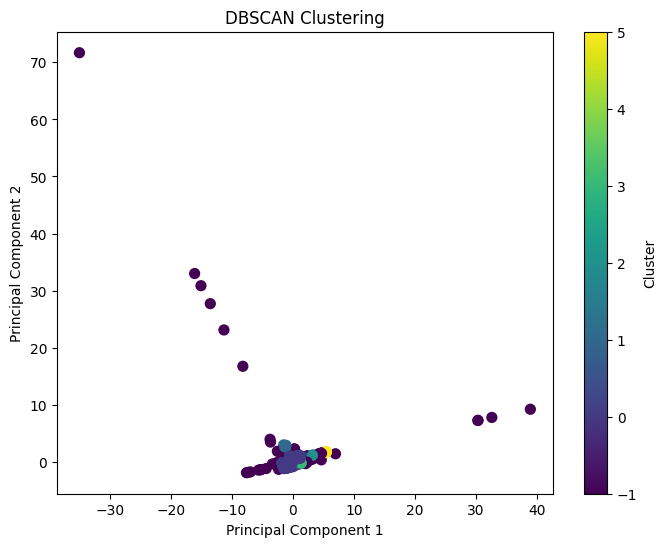

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [12]:
from sklearn.metrics import silhouette_score

cluster_labels = set(labels) - {-1}

if len(cluster_labels) >= 2:

    score = silhouette_score(
        X_scaled,
        labels
    )

    print("DBSCAN Silhouette Score:", score)

else:

    print("Silhouette Score cannot be calculated.")
    print("DBSCAN did not create at least 2 clusters.")

DBSCAN Silhouette Score: 0.5363690060727853


In [13]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

In [14]:
df.to_csv(
    '/content/online_retail_combined.csv',
    index=False
)

print("DBSCAN result saved successfully!")

DBSCAN result saved successfully!
